## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from datetime import datetime, timezone

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    classification_report,
    ConfusionMatrixDisplay,
)

plt.style.use("default")

PROCESSED_DATA_PATH = "../data/processed/telco_customer_churn_clean.csv"
MODEL_PATH = "../artifacts/churn_model_package.joblib"

In [2]:
df = pd.read_csv(PROCESSED_DATA_PATH)

TARGET = "Churn"

categorical_features = [
    col for col in df.select_dtypes(include="object").columns
    if col != TARGET
]

numeric_features = [
    col for col in df.select_dtypes(include=["number"]).columns
    if col != TARGET
]

print("Target:", TARGET)
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Target: Churn
Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Train-Test Split (stratified)

In [3]:
X = df.drop(columns=[TARGET])
y = (df[TARGET] == "Yes").astype(int)

# 70 / 15 / 15 (stratified split)
# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

Train: (4922, 19)
Validation: (1055, 19)
Test: (1055, 19)

Train class distribution:
Churn
0    0.734254
1    0.265746
Name: proportion, dtype: float64

Validation class distribution:
Churn
0    0.733649
1    0.266351
Name: proportion, dtype: float64

Test class distribution:
Churn
0    0.734597
1    0.265403
Name: proportion, dtype: float64


In [4]:
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    drop="if_binary",
    handle_unknown="ignore",
    sparse_output=True
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## Modeling

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("\nXGBoost scale_pos_weight:", scale_pos_weight)

logreg_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

rf_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

gb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            class_weight="balanced",
            random_state=42
        ))
    ]
)

xgb_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

lgbm_pipe = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            class_weight="balanced",
            random_state=42,
            verbose=-1,
        ))
    ]
)


XGBoost scale_pos_weight: 2.7629969418960245


In [6]:
def evaluate_fitted_model(pipe, X, y, threshold=0.5):

    y_proba = pipe.predict_proba(X)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    return {
        "PR_AUC": average_precision_score(y, y_proba),
        "ROC_AUC": roc_auc_score(y, y_proba),
        "Recall": recall_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "F1": f1_score(y, y_pred),
    }

models = {
    "LogisticRegression": logreg_pipe,
    "RandomForest": rf_pipe,
    "GradientBoosting": gb_pipe,
    "XGBoost": xgb_pipe,
    "LightGBM": lgbm_pipe
}

results = []

for name, pipe in models.items():
    print(f"Training {name}...")

    pipe.fit(X_train, y_train)

    metrics = evaluate_fitted_model(pipe, X_val, y_val)
    metrics["Model"] = name

    results.append(metrics)

Training LogisticRegression...
Training RandomForest...
Training GradientBoosting...
Training XGBoost...
Training LightGBM...


c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [7]:
def make_results_df(results, metrics=None, sort_by="PR_AUC", ascending=False):
    df = pd.DataFrame(results).set_index("Model")

    if metrics is not None:
        df = df[metrics]

    return df.sort_values(by=sort_by, ascending=ascending)

results_df = make_results_df(results, ["PR_AUC", "ROC_AUC"])
display(results_df)

,PR_AUC,ROC_AUC
Model,,
XGBoost,0.678140,0.845619
GradientBoosting,0.666940,0.840285
LightGBM,0.664108,0.835593
LogisticRegression,0.655551,0.853143
RandomForest,0.623192,0.823007


## Hyperparameter tuning

In [8]:
SCORING = "average_precision"
N_JOBS = -1
RANDOM_STATE = 42

CV_SPLITTER = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# LOGISTIC REGRESSION (small grid)
param_grid_lr = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 50]
}

# XGBOOST (expanded space)
param_dist_xgb = {
    "model__n_estimators": [200, 300, 500, 800],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.6, 0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [1, 5, 10],
    "model__scale_pos_weight": [
        scale_pos_weight * 0.5,
        scale_pos_weight,
        scale_pos_weight * 1.5
    ]
}

# LIGHTGBM (expanded space)
param_dist_lgbm = {
    "model__n_estimators": [200, 300, 500, 800],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63, 127],
    "model__max_depth": [-1, 5, 10],
    "model__min_child_samples": [10, 20, 40],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__colsample_bytree": [0.6, 0.8, 1.0],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [0, 1, 5]
}

# Gradient Boosting
param_dist_gb = {
    "model__max_iter": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_samples_leaf": [20, 40, 60]
}

# Random Forest
param_dist_rf = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 5, 10, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2"]
}

# SEARCH OBJECTS (ONLY TOP MODELS)
searches = {
    "LogisticRegression": GridSearchCV(
        logreg_pipe,
        param_grid_lr,
        scoring=SCORING,
        cv=CV_SPLITTER,
        n_jobs=N_JOBS
    ),

    "RandomForest": RandomizedSearchCV(
        rf_pipe,
        param_dist_rf,
        n_iter=40,
        scoring=SCORING,
        cv=CV_SPLITTER,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    "GradientBoosting": RandomizedSearchCV(
        gb_pipe,
        param_dist_gb,
        n_iter=40,
        scoring=SCORING,
        cv=CV_SPLITTER,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    "XGBoost": RandomizedSearchCV(
        xgb_pipe,
        param_dist_xgb,
        n_iter=100,
        scoring=SCORING,
        cv=CV_SPLITTER,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    ),

    "LightGBM": RandomizedSearchCV(
        lgbm_pipe,
        param_dist_lgbm,
        n_iter=50,
        scoring=SCORING,
        cv=CV_SPLITTER,
        random_state=RANDOM_STATE,
        n_jobs=N_JOBS
    )
}

# RUN TUNING + VALIDATION EVAL
tuned_results = []
tuned_best_pipelines = {}

for name, search in searches.items():
    print(f"\nTuning {name}...")

    search.fit(X_train, y_train)

    print(f"\n{name} best parameters:")
    print(search.best_params_)
    print(f"{name} best CV PR-AUC: {search.best_score_:.4f}")

    best_pipe = search.best_estimator_
    tuned_best_pipelines[name] = best_pipe

    metrics = evaluate_fitted_model(best_pipe, X_val, y_val)
    metrics["Model"] = name

    tuned_results.append(metrics)


Tuning LogisticRegression...

LogisticRegression best parameters:
{'model__C': 1}
LogisticRegression best CV PR-AUC: 0.6701

Tuning RandomForest...

RandomForest best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 5, 'model__max_features': 'log2', 'model__max_depth': 10}
RandomForest best CV PR-AUC: 0.6714

Tuning GradientBoosting...

GradientBoosting best parameters:
{'model__min_samples_leaf': 60, 'model__max_iter': 100, 'model__max_depth': 7, 'model__learning_rate': 0.05}
GradientBoosting best CV PR-AUC: 0.6682

Tuning XGBoost...

XGBoost best parameters:
{'model__subsample': 0.7, 'model__scale_pos_weight': np.float64(1.3814984709480123), 'model__reg_lambda': 5, 'model__reg_alpha': 0, 'model__n_estimators': 800, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.6}
XGBoost best CV PR-AUC: 0.6774

Tuning LightGBM...

LightGBM best parameters:
{'model__subsample': 0.6, 'm

c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [9]:
tuned_results_df = make_results_df(tuned_results, ["PR_AUC", "ROC_AUC"])
display(tuned_results_df)

,PR_AUC,ROC_AUC
Model,,
GradientBoosting,0.690641,0.849931
XGBoost,0.687402,0.852536
LightGBM,0.683765,0.848814
RandomForest,0.667742,0.847345
LogisticRegression,0.655551,0.853143


pick GradientBoosting, XGBoost, LightGBM

## Calibration

In [10]:
calibrated_models = {}
calibration_results = []

top_models = ["GradientBoosting", "XGBoost", "LightGBM"]

for model in top_models:

    print(f"\nCalibrating {model}...")

    base_model = tuned_best_pipelines[model]

    calibrated = CalibratedClassifierCV(
        FrozenEstimator(base_model),
        method="sigmoid"
    )

    calibrated.fit(X_val, y_val)

    # store calibrated model
    calibrated_models[model] = calibrated

    # calibrated probabilities
    probs = calibrated.predict_proba(X_val)[:, 1]

    # metrics on validation
    pr_auc = average_precision_score(y_val, probs)
    roc_auc = roc_auc_score(y_val, probs)
    brier = brier_score_loss(y_val, probs)

    calibration_results.append({
        "Model": model,
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc,
        "Val_Brier": brier
    })

calibration_df = (
    pd.DataFrame(calibration_results)
      .set_index("Model")
      .sort_values("Val_Brier", ascending=True)
)

display(calibration_df)


Calibrating GradientBoosting...

Calibrating XGBoost...

Calibrating LightGBM...


c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: U

,PR_AUC,ROC_AUC,Val_Brier
Model,,,
XGBoost,0.687402,0.852536,0.132131
GradientBoosting,0.690641,0.849931,0.132402
LightGBM,0.683765,0.848814,0.133806


c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\arjun\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


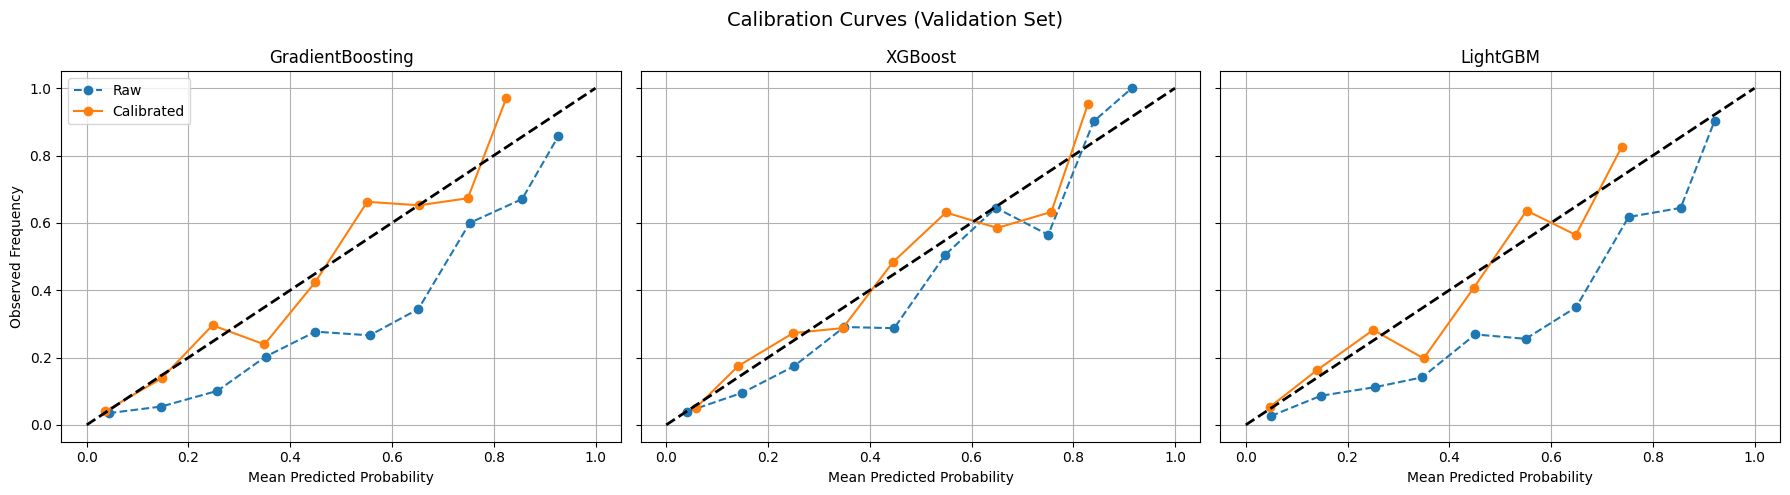

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, name in zip(axes, top_models):

    base_model = tuned_best_pipelines[name]
    calibrated_model = calibrated_models[name]

    raw_probs = base_model.predict_proba(X_val)[:,1]
    cal_probs = calibrated_model.predict_proba(X_val)[:,1]

    frac_raw, mean_raw = calibration_curve(
        y_val, raw_probs, n_bins=10, strategy="uniform"
    )

    frac_cal, mean_cal = calibration_curve(
        y_val, cal_probs, n_bins=10, strategy="uniform"
    )

    ax.plot(mean_raw, frac_raw, linestyle="--", marker="o", label="Raw")
    ax.plot(mean_cal, frac_cal, marker="o", label="Calibrated")
    ax.plot([0,1], [0,1], "k--", linewidth=2)

    ax.set_title(name)
    ax.set_xlabel("Mean Predicted Probability")
    ax.grid(True)

axes[0].set_ylabel("Observed Frequency")
axes[0].legend()

plt.suptitle("Calibration Curves (Validation Set)", fontsize=14)
plt.tight_layout()
plt.show()

pick XGBoost

## Threshold optimization

In [21]:
final_model = calibrated_models["XGBoost"]

val_probs = final_model.predict_proba(X_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_val, val_probs)

# precision & recall are length N+1, thresholds length N
precision = precision[:-1]
recall = recall[:-1]

df_thresh = pd.DataFrame({
    "recall": recall,
    "precision": precision,
    "threshold": thresholds
})

TARGET_PRECISIONS = [0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]

results = []

for p in TARGET_PRECISIONS:

    valid = df_thresh[df_thresh["precision"] >= p]

    if valid.empty:
        print(f"\nNo threshold found for precision >= {p}")
        continue

    # pick row with max recall under this precision constraint
    best_row = valid.loc[valid["recall"].idxmax()]

    results.append({
        "precision": best_row["precision"],
        "recall": best_row["recall"],
        "threshold": best_row["threshold"]
    })

df_results = pd.DataFrame(results)
display(df_results.round(4))

,precision,recall,threshold
0,0.4504,0.9039,0.1172
1,0.5000,0.8505,0.1791
2,0.5504,0.7580,0.2837
3,0.6012,0.7082,0.3436
4,0.6511,0.6441,0.4154
5,0.7005,0.5160,0.5296
6,0.7521,0.3238,0.6833


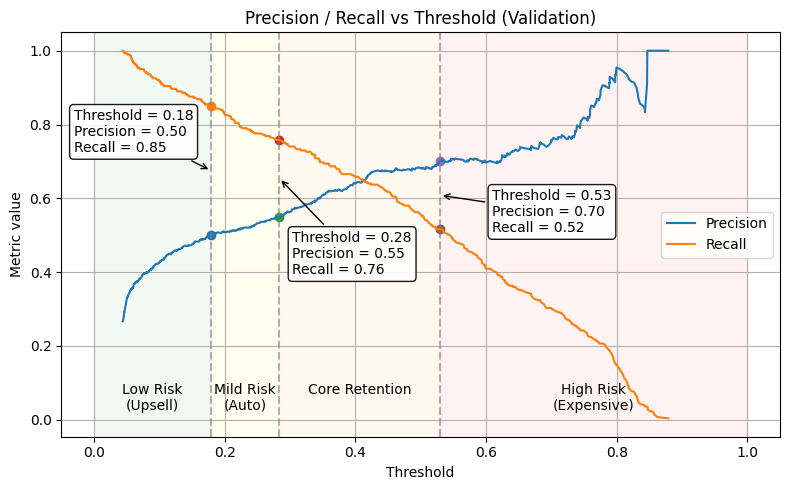

In [26]:
best_thresholds = [0.1791, 0.2837, 0.5296]

plt.figure(figsize=(8,5))

plt.plot(df_thresh["threshold"], df_thresh["precision"], label="Precision")
plt.plot(df_thresh["threshold"], df_thresh["recall"], label="Recall")

# 4 ACTION REGIONS
t1, t2, t3 = sorted(best_thresholds)

# Region 1: Low risk (No action / upsell)
plt.axvspan(0, t1, color="green", alpha=0.05)

# Region 2: Mild risk (Cheap automated actions)
plt.axvspan(t1, t2, color="yellow", alpha=0.06)

# Region 3: Core retention
plt.axvspan(t2, t3, color="orange", alpha=0.06)

# Region 4: High risk (Expensive actions)
plt.axvspan(t3, 1, color="red", alpha=0.05)

# DYNAMIC REGION LABELS
y_top = 0.1

r1_center = t1 / 2
r2_center = (t1 + t2) / 2
r3_center = (t2 + t3) / 2
r4_center = (t3 + 1) / 2

plt.text(r1_center, y_top, "Low Risk\n(Upsell)", ha="center", va="top")
plt.text(r2_center, y_top, "Mild Risk\n(Auto)", ha="center", va="top")
plt.text(r3_center, y_top, "Core Retention", ha="center", va="top")
plt.text(r4_center, y_top, "High Risk\n(Expensive)", ha="center", va="top")

# Explicit (dx, dy) placements for clean layout
placements = [
    (-0.21,  0.05),
    (0.02, -0.26),
    (0.08,  -0.1)
]

for t, (dx, dy) in zip(best_thresholds, placements):

    idx = (df_thresh["threshold"] - t).abs().idxmin()

    best_p = df_thresh.loc[idx, "precision"]
    best_r = df_thresh.loc[idx, "recall"]

    mid_y = (best_p + best_r) / 2

    plt.axvline(t, linestyle="--", color="gray", alpha=0.6)
    plt.scatter(t, best_p)
    plt.scatter(t, best_r)

    plt.annotate(
        f"Threshold = {t:.2f}\n"
        f"Precision = {best_p:.2f}\n"
        f"Recall = {best_r:.2f}",
        xy=(t, mid_y),
        xytext=(t + dx, mid_y + dy),
        arrowprops=dict(arrowstyle="->", lw=1),
        bbox=dict(boxstyle="round", fc="white", alpha=0.9)
    )

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Precision / Recall vs Threshold (Validation)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Final evaluation (Test set)

In [30]:
FINAL_THRESHOLDS = [0.1791, 0.2837, 0.5296]

test_probs = final_model.predict_proba(X_test)[:, 1]

# AUC metrics (threshold independent)
pr_auc = average_precision_score(y_test, test_probs)
roc_auc = roc_auc_score(y_test, test_probs)

rows = []

for t in FINAL_THRESHOLDS:

    test_preds = (test_probs >= t).astype(int)

    rows.append({
        "Threshold": t,
        "PR_AUC": pr_auc,
        "ROC_AUC": roc_auc,
        "Recall": recall_score(y_test, test_preds),
        "Precision": precision_score(y_test, test_preds),
        "F1": f1_score(y_test, test_preds),
    })

results_df = (
    pd.DataFrame(rows)
      .set_index("Threshold")
      .round(4)
)

display(results_df)

,PR_AUC,ROC_AUC,Recall,Precision,F1
Threshold,,,,,
0.1791,0.6102,0.8312,0.8357,0.4785,0.6086
0.2837,0.6102,0.8312,0.7250,0.5413,0.6198
0.5296,0.6102,0.8312,0.4679,0.6121,0.5304



Classification Report (Test Set):

              precision    recall  f1-score   support

           0     0.8868    0.7781    0.8289       775
           1     0.5413    0.7250    0.6198       280

    accuracy                         0.7640      1055
   macro avg     0.7140    0.7515    0.7244      1055
weighted avg     0.7951    0.7640    0.7734      1055



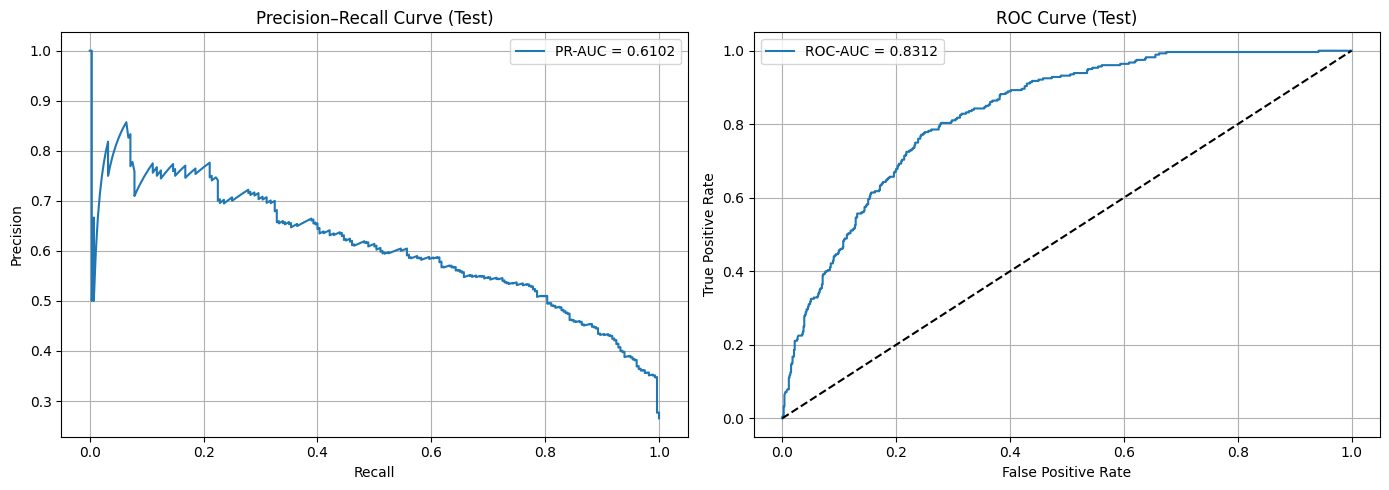

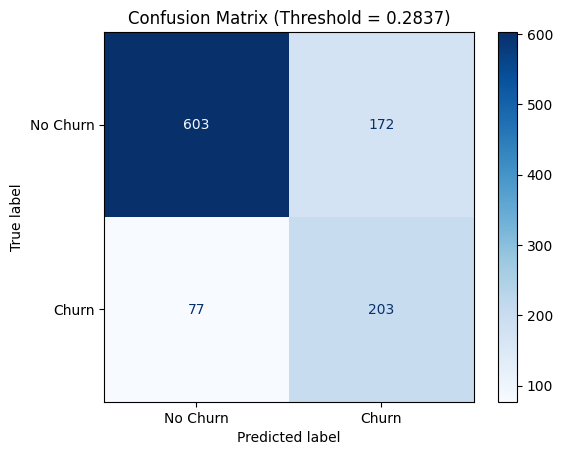

In [31]:
FINAL_THRESHOLD = 0.2837

test_preds = (test_probs >= FINAL_THRESHOLD).astype(int)

print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, test_preds, digits=4))

# PR + ROC
prec_curve, rec_curve, _ = precision_recall_curve(y_test, test_probs)
fpr, tpr, _ = roc_curve(y_test, test_probs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR Curve
axes[0].plot(rec_curve, prec_curve, label=f"PR-AUC = {pr_auc:.4f}")
axes[0].set_title("Precision–Recall Curve (Test)")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].legend()
axes[0].grid(True)

# ROC Curve
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
axes[1].plot([0,1], [0,1], "k--")
axes[1].set_title("ROC Curve (Test)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, test_preds)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot(cmap="Blues")

plt.title(f"Confusion Matrix (Threshold = {FINAL_THRESHOLD})")
plt.show()

In [32]:
# Confusion matrix values
tn, fp, fn, tp = cm.ravel()

total_customers = len(y_test)
actual_churners = y_test.sum()
predicted_churners = tp + fp

churn_rate = actual_churners / total_customers
capture_rate = tp / actual_churners
precision_campaign = tp / predicted_churners
contact_rate = predicted_churners / total_customers

churn_stats = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Actual Churners",
        "Churn Rate",
        "Customers Flagged",
        "% Customers Contacted",
        "True Churners Captured",
        "Churn Capture Rate (Recall)",
        "Campaign Precision",
        "False Positives",
        "Missed Churners"
    ],
    "Value": [
        total_customers,
        actual_churners,
        round(churn_rate, 3),
        predicted_churners,
        round(contact_rate, 3),
        tp,
        round(capture_rate, 3),
        round(precision_campaign, 3),
        fp,
        fn
    ]
})

display(churn_stats)

,Metric,Value
0,Total Customers,1055.000
1,Actual Churners,280.000
2,Churn Rate,0.265
3,Customers Flagged,375.000
4,% Customers Contacted,0.355
5,True Churners Captured,203.000
6,Churn Capture Rate (Recall),0.725
7,Campaign Precision,0.541
8,False Positives,172.000
9,Missed Churners,77.000


## Model serialization

In [38]:
model_package = {
    "model": final_model,
    "thresholds": {
        "aggressive": 0.1791,
        "balanced": 0.2837,
        "conservative": 0.5296
    },
    "metrics": {
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc)
    },
    "trained_on": datetime.now(timezone.utc).isoformat()
}

joblib.dump(model_package, MODEL_PATH)

print(f"Model package saved to {MODEL_PATH}")

Model package saved to ../artifacts/churn_model_package.joblib
